This is the final notebook -- notebook 6. The purpose of this notebook is to explore selected features impact on salary with respect to player's country of origin.

NOTE: The images in this notebook have a different background compared to our technical report for ease of viewing.

## 6. Statistical Inference on Population Mean Salary Between International and USA NBA Players 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import altair as alt


# read data with no outliers
salary_stats = pd.read_csv('df_final_no_outliers.csv',index_col=0)

In [ ]:
# browse each columns in data
salary_stats.columns

Index(['PLAYER_NAME', 'NICKNAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'GP',
       'W', 'L', 'W_PCT', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'TOV',
       'STL', 'BLK', 'BLKA', 'PF', 'PFD', 'PTS', 'PLUS_MINUS',
       'NBA_FANTASY_PTS', 'DD2', 'TD3', 'WNBA_FANTASY_PTS', 'season_id',
       'COUNTRY', 'E_OFF_RATING', 'OFF_RATING', 'sp_work_OFF_RATING',
       'E_DEF_RATING', 'DEF_RATING', 'sp_work_DEF_RATING', 'E_NET_RATING',
       'NET_RATING', 'sp_work_NET_RATING', 'AST_PCT', 'AST_TO', 'AST_RATIO',
       'OREB_PCT', 'DREB_PCT', 'REB_PCT', 'TM_TOV_PCT', 'E_TOV_PCT', 'EFG_PCT',
       'TS_PCT', 'USG_PCT', 'E_USG_PCT', 'E_PACE', 'PACE', 'PACE_PER40',
       'sp_work_PACE', 'PIE', 'POSS', 'FGM_PG', 'FGA_PG', 'Names', 'Positions',
       'AAV+Bonus', 'Year_List', 'Salary', 'Outliers', 'Era'],
      dtype='object')

In our analysis, we are focusing on examining the average salary and statistical performance of NBA players across different countries and positions. To achieve this, our methodology involves grouping the data based on three key factors: PLAYER_ID, COUNTRY, and Positions. Within these distinct groupings, we will calculate the mean values for salary and other specific statistical metrics

In [ ]:
# groupby 'PLAYER_ID','COUNTRY','Positions' and calculated the mean values 
# for salary and other specific statistical metrics
bio_salary_stats = salary_stats.groupby(['PLAYER_ID','PLAYER_NAME','COUNTRY','Positions'])[[
    'AAV+Bonus','FGM_PG', 'AGE', 'FG3A', 'DREB_PCT', 'OREB_PCT', 'DEF_RATING'
    ]].mean().reset_index()

In our upcoming steps, we will be examining the distributions of both the original salary data and the log-transformed salary data

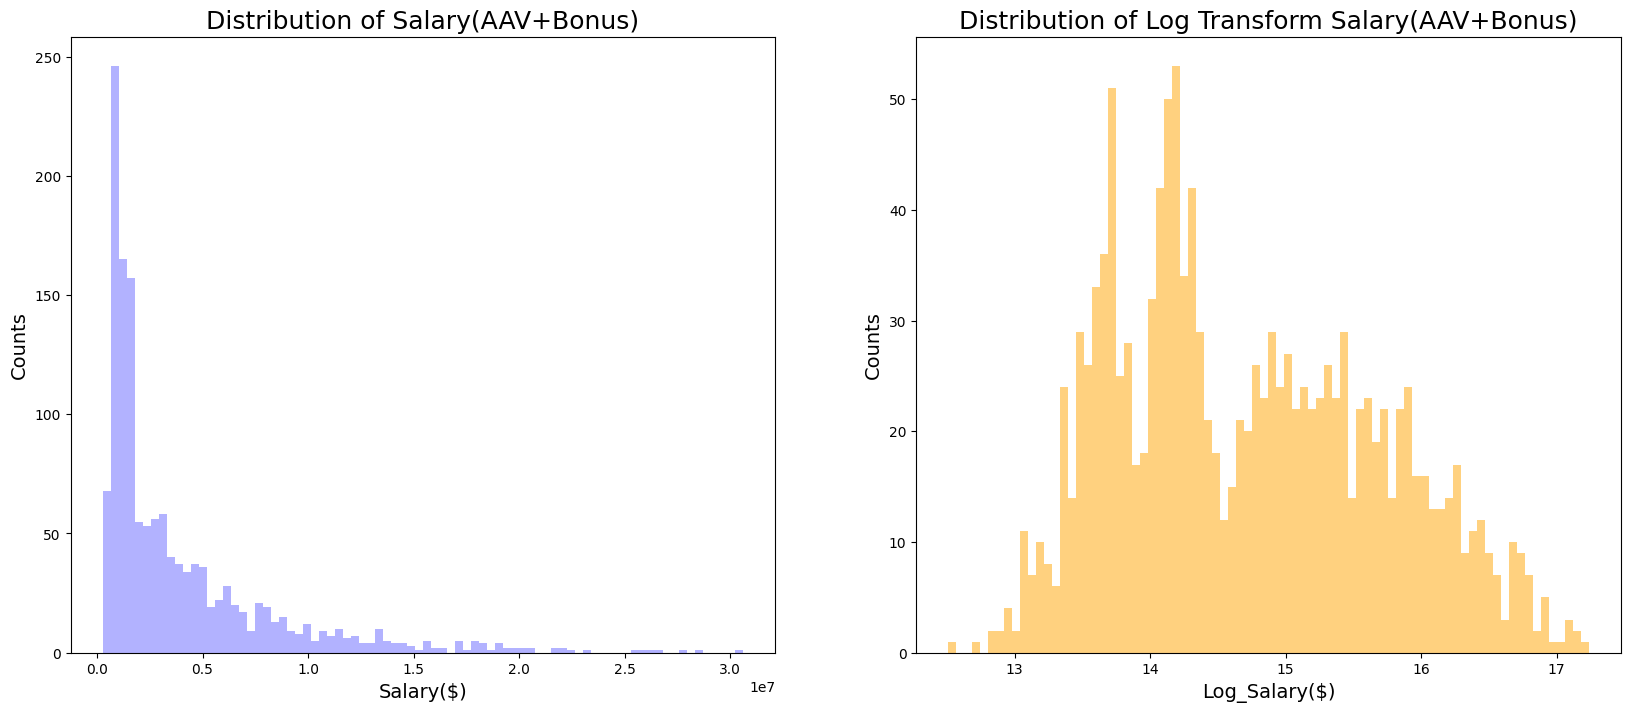

((array([-3.28992781, -3.03161723, -2.88790057, ...,  2.88790057,
          3.03161723,  3.28992781]),
  array([12.50890684, 12.6961837 , 12.82330753, ..., 17.13357372,
         17.1608535 , 17.23684226])),
 (0.957120278253031, 14.72072821919145, 0.9854653876671707))

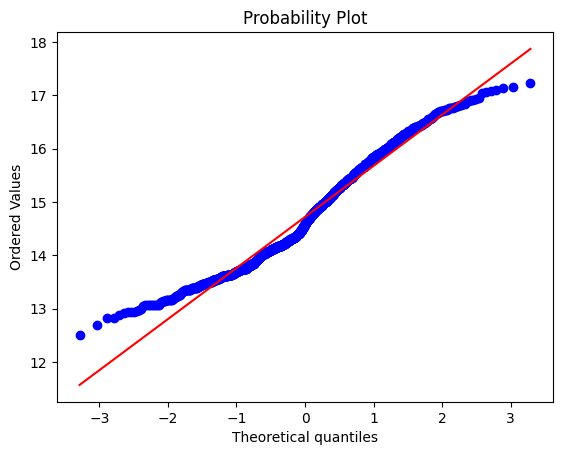

In [ ]:
'''The following figures are adapted to be viewed on any jupyter notebook but were made transparent for the 
technical report with white labels due to the black background of the report. The below figures are therefore
different in color scheme from the technical report but demonstrate similar findings.'''

fig,ax = plt.subplots(1,2,figsize=(20,8))

# Create histogram for average salary
ax[0].hist(bio_salary_stats['AAV+Bonus'],bins=80,color='b',alpha=0.3)

# Create histogram for log transform average salary
salary_log = np.log((bio_salary_stats['AAV+Bonus']))
ax[1].hist(salary_log,bins=80,color='orange',alpha=0.5)


ax[0].set_xlabel('Salary($)',fontsize=14)
ax[0].set_ylabel('Counts',fontsize=14)
ax[0].set_title('Distribution of Salary(AAV+Bonus)',fontsize=18)
ax[0].tick_params(axis='both')


ax[1].set_xlabel('Log_Salary($)',fontsize=14)
ax[1].set_ylabel('Counts',fontsize=14)
ax[1].set_title('Distribution of Log Transform Salary(AAV+Bonus)',fontsize=18)
ax[1].tick_params(axis='both')



plt.show()

stats.probplot(salary_log, dist=stats.norm, plot=plt.gca())

We have identified that the salary distribution displays a right-skewed trend. Nonetheless, following a logarithmic transformation of the salary data, the distribution now exhibits a much closer approximation to a normal distribution.

In [ ]:
# Create a new log transform salary column 
bio_salary_stats['log_AAV+Bonus'] = salary_log

Then we will create a bar chart to compare the logarithmic transformation of the salary between USA and International NBA players

In [ ]:
base = alt.Chart(bio_salary_stats).mark_bar(size=20).encode(
    alt.X('COUNTRY:N'),
    alt.Y('mean(log_AAV+Bonus)'),
    color='COUNTRY:N'
    ).properties(
    width=80,
    height=180)
base

alt.Chart(...)

We've noted that the average logarithmic transformation of salaries for USA and international NBA players shows a striking similarity. This has arouse our interest in exploring whether there is a statistically significant disparity in the average salaries between these two groups. To investigate this question, we will be conducting a rigorous statistical inference analysis

### a) Research Question

- Research question : Is there a significant average salary difference between USA and International NBA Players? 

- Population: All NBA Players

- Parameter of Interest(u1-u2): Mean salary difference(log_AAV+Bonus)

### b) Define Hypothesis

H0 = There is no difference in mean salary between USA and International NBA players(u1 = u2)

Ha = There is difference in mean salary between USA and International NBA players(u1 != u2)

In [ ]:
log_int_salary = bio_salary_stats.loc[bio_salary_stats['COUNTRY'] == 'international', ['COUNTRY', 'log_AAV+Bonus']]
log_us_salary = bio_salary_stats.loc[bio_salary_stats['COUNTRY'] == 'USA', ['COUNTRY', 'log_AAV+Bonus']]

### c) Examine the Data

n(internation)=298, n(USA) = 1085

mean(internation) = 14.922, mean(USA) = 14.665

In [ ]:
pd.concat([log_int_salary.describe(),log_us_salary.describe()],axis=1,keys=['international', 'USA'])

,international,USA
,log_AAV+Bonus,log_AAV+Bonus
count,298.000000,1085.000000
mean,14.922017,14.665443
std,0.948799,0.968309
min,12.508907,12.696184
25%,14.181281,13.842565
50%,14.897773,14.440726
75%,15.677989,15.401681
max,16.930298,17.236842


In [ ]:
base = alt.Chart(bio_salary_stats).mark_boxplot(size=30).encode(
    x=alt.X('COUNTRY:N'),
    y=alt.Y('log_AAV+Bonus:Q'),  
    color='COUNTRY:N'
).properties(
    width=150,
    height=200
)

base

alt.Chart(...)

### d) Check Assumptions

Let's check the normality of both group. If two groups are approximately bell-shaped, we can assume that the population of the two groups will also normally distributed 

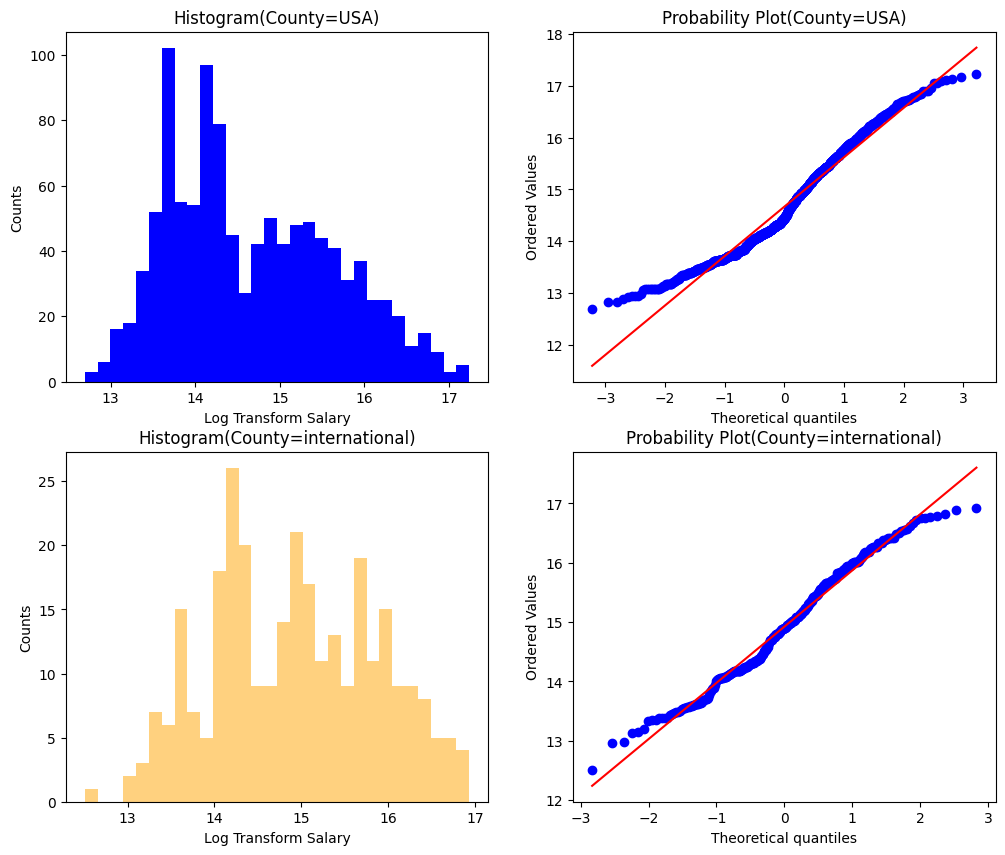

In [ ]:
import scipy.stats as stats


fig, ax = plt.subplots(2,2,figsize=(12,10))
ax[0,0].hist(log_us_salary['log_AAV+Bonus'],bins=30,color='b')
ax[1,0].hist(log_int_salary['log_AAV+Bonus'],bins=30,alpha=0.5, color='orange')
stats.probplot(log_us_salary['log_AAV+Bonus'], dist=stats.norm, plot=ax[0,1])
stats.probplot(log_int_salary['log_AAV+Bonus'], dist=stats.norm, plot=ax[1,1])
ax[0,0].set_title('Histogram(County=USA)')
ax[1,0].set_title('Histogram(County=international)')
ax[0,1].set_title('Probability Plot(County=USA)')
ax[1,1].set_title('Probability Plot(County=international)')

ax[1,0].set_ylabel('Counts')
ax[0,0].set_ylabel('Counts')
ax[0,0].set_xlabel('Log Transform Salary')
ax[1,0].set_xlabel('Log Transform Salary')
plt.show()

both groups seems a little bit departure from normal distribution, however since we have large sample size for both USA and international group, normality assumption is not as crucial. We can apply Central Limit Theorem and move on anyway.

### e) Calculate Test Statistic and P-value

H0 : u1-u2=0

Ha : u1-u2 !=0

Significant level = 0.05

In [ ]:
best_estimate = log_us_salary['log_AAV+Bonus'].mean() - log_int_salary['log_AAV+Bonus'].mean()
best_estimate

-0.25657414888442354

<img src="Screenshot 2023-09-23 at 11.40.31 AM.png" width="" align="" />

<img src="Screenshot 2023-09-23 at 11.40.16 AM.png" width="" align="" />

Because the IQR and standard deviation are very similar, the pooled approach will be used

In [ ]:
from scipy import stats

t,p = stats.ttest_ind(log_us_salary['log_AAV+Bonus'],log_int_salary['log_AAV+Bonus'])
print(f't_statistic = {t} \np-Value = {p}')

t_statistic = -4.068945292705707 
p-Value = 4.989997739534094e-05


### f) Conclusion

Our t statistic equals -4.06 which means our sample mean is around 4.06 standard deviation below our null difference of 0. In addition p-value is extremely smaller than our significant level 0.05, so we have strong evidence to reject the null hypothesis. Therefore based on our estimated difference in sample means, there is a significant difference between the population mean salary for USA NBA players and the population mean salary for international players.

## 2. Exploration of Mean Salary and Statistical Performance Among Different Positions and Countries

Let's first have a look at the number of players among different positions and countries. 

In [ ]:
base1 = alt.Chart(bio_salary_stats).mark_bar(size=20).encode(
    alt.X('COUNTRY:N'),
    alt.Y('count(log_AAV+Bonus)'),
    alt.Color('COUNTRY:N')
).properties(
    width=80,
    height=180
).facet(
    column=alt.Column('Positions:N', title='Positions')
)
base1

alt.FacetChart(...)

We've observed that, in general, USA players tend to have higher salaries than international players, particularly in the PG and SG positions. Notably, there are more international players occupying the Center position compared to other positions. In our next steps, we will create scatter plots to examine the salary distributions for players in each country group and position. Additionally, we plan to generate line charts to illustrate the trends in mean salaries across different countries and positions

In [ ]:
base2 = alt.Chart(bio_salary_stats).mark_point(size=20).encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('AAV+Bonus'),
    alt.Color('COUNTRY:N')
).properties(
    width=120,
    height=180)


mean = alt.Chart(bio_salary_stats).mark_line(color = 'red').encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(AAV+Bonus):Q')
)


salary_chart = (base2 + mean).facet(
    column=alt.Column('Positions:N' ,title= None)
)
salary_chart

alt.FacetChart(...)

We've noted that the top salaries are primarily earned by USA players. However, on average, international players tend to have higher salaries compared to USA players, except in the case of the small forward position. Moving forward in our analysis, we plan to incorporate selected statistical performance metrics. To facilitate a meaningful comparison of trends across countries and positions, we will standardize or normalize these performance statistics into a common unit.

In [ ]:
from sklearn.preprocessing import StandardScaler

stats_subset = bio_salary_stats[['FGM_PG', 'AGE', 'FG3A', 'DREB_PCT', 'OREB_PCT', 'DEF_RATING']]
scaler = StandardScaler()
data=scaler.fit_transform(stats_subset)
stats_subset_norm = pd.DataFrame(data, columns=['FGM_PG', 'AGE', 'FG3A', 'DREB_PCT', 'OREB_PCT', 'DEF_RATING'])
stats_subset_norm

,FGM_PG,AGE,FG3A,DREB_PCT,OREB_PCT,DEF_RATING
0,0.126890,3.454921,-0.571330,-0.568072,-0.609546,-0.419388
1,-0.832070,3.454921,-0.858392,0.625566,0.065301,-0.046028
2,-0.239771,3.454921,1.599578,0.191516,-0.620984,-0.424175
3,-0.662842,3.454921,-0.853907,0.942061,0.213996,-0.548628
4,0.860212,3.074358,-0.793803,2.249637,-0.001040,-0.754455
...,...,...,...,...,...,...
1378,-0.211567,-0.477560,-0.678979,0.245772,0.442758,-0.361948
1379,-0.155157,0.283566,0.855010,-1.056378,-0.197775,1.150638
1380,-0.832070,-0.477560,-0.831480,-0.604243,-1.021317,0.940025
1381,1.311487,-0.477560,-0.786627,-1.617026,0.580015,1.380398


In [ ]:
# combine the standardized stats with original bio_salary_stats
interim_da = bio_salary_stats.drop(['FGM_PG', 'AGE', 'FG3A', 'DREB_PCT', 'OREB_PCT', 'DEF_RATING'],axis=1)
bio_salary_stats_norm = pd.concat([interim_da,stats_subset_norm],axis=1)
bio_salary_stats_norm 

,PLAYER_ID,PLAYER_NAME,COUNTRY,Positions,AAV+Bonus,log_AAV+Bonus,FGM_PG,AGE,FG3A,DREB_PCT,OREB_PCT,DEF_RATING
0,255,Grant Hill,USA,Small Forward,4250516.5,15.262551,0.126890,3.454921,-0.571330,-0.568072,-0.609546,-0.419388
1,436,Juwan Howard,USA,Power Forward,783469.5,13.571487,-0.832070,3.454921,-0.858392,0.625566,0.065301,-0.046028
2,467,Jason Kidd,USA,Point Guard,5698333.5,15.555684,-0.239771,3.454921,1.599578,0.191516,-0.620984,-0.424175
3,703,Kurt Thomas,USA,Power Forward,1352181.0,14.117229,-0.662842,3.454921,-0.853907,0.942061,0.213996,-0.548628
4,708,Kevin Garnett,USA,Power Forward,12270000.0,16.322668,0.860212,3.074358,-0.793803,2.249637,-0.001040,-0.754455
...,...,...,...,...,...,...,...,...,...,...,...,...
1378,1631288,Jamal Cain,USA,Small Forward,1017781.0,13.833135,-0.211567,-0.477560,-0.678979,0.245772,0.442758,-0.361948
1379,1631323,Simone Fontecchio,international,Small Forward,3125000.0,14.954945,-0.155157,0.283566,0.855010,-1.056378,-0.197775,1.150638
1380,1631367,Jacob Gilyard,USA,Point Guard,1017781.0,13.833135,-0.832070,-0.477560,-0.831480,-0.604243,-1.021317,0.940025
1381,1631466,Jeenathan Williams,USA,Shooting Guard,1017781.0,13.833135,1.311487,-0.477560,-0.786627,-1.617026,0.580015,1.380398


In our next step, we will generate a line chart. We will represent mean statistical performance metrics on the Y-axis, with different positions being distinguished by colors. The X-axis will represent countries, and we will create separate plots for each performance statistic

In [ ]:
# Create a chart for FGM_PG
FGM_PG = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(FGM_PG)', title='FGM_PG'),  # Use title to set the legend label
    color=alt.Color('Positions:N', legend=alt.Legend(title='Statistics')),  # Color by Positions
).properties(
    width=80,
    height=180
)

# Create a chart for FG3A
FG3A = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(FG3A)', title='FG3A'),
    color=alt.Color('Positions:N', legend=None),  
).properties(
    width=80,
    height=180
)

# Create a chart for OREB
OREB = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(OREB_PCT)', title='OREB_PCT'),
    color=alt.Color('Positions:N', legend=None),  # Disable legend for OREB
).properties(
    width=80,
    height=180
)

# Create a chart for DREB
DREB = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(DREB_PCT)', title='DREB_PCT'),
    color=alt.Color('Positions:N', legend=None),  # Disable legend for DREB
).properties(
    width=80,
    height=180
)

# Create a chart for E_USG_PCT
AGE = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N',title= None),
    alt.Y('mean(AGE)', title='AGE'),
    color=alt.Color('Positions:N', legend=None),  # Disable legend for E_USG_PCT
).properties(
    width=80,
    height=180
)

# Create a chart for DEF_RATING
DEF_RATING = alt.Chart(bio_salary_stats_norm).mark_line().encode(
    alt.X('COUNTRY:N', title= None),
    alt.Y('mean(DEF_RATING)', title='DEF_RATING'),
    color=alt.Color('Positions:N', legend=None),  # Disable legend for DEF_RATING
).properties(
    width=80,
    height=180
)

# Combine the charts horizontally
combined_chart = FGM_PG | FG3A | OREB | DREB | AGE | DEF_RATING
(salary_chart&combined_chart).resolve_scale(color='independent')

alt.VConcatChart(...)

By combining the salary chart with the performance statistics chart, we can gain deeper insights into our approach to allocating international players within our team. For example, if we would like to find a Small Forward player who can score effectively and excel in three-point shooting, with less emphasis on defensive rating (possibly leaning towards an offensive-minded Small Forward), we should prioritize our attention on international players. This preference stems from the observation that international players tend to command relatively lower salaries compared to their USA counterparts while demonstrating strong performance in scoring and three-point shooting.

Moreover, from the perspective of NBA players, they can glean valuable insights from this plot to pinpoint areas where they might need skill enhancement. For instance, if a USA Point Guard player aspires to attain a competitive salary level when competing with international players, it is advisable to place greater emphasis on refining their scoring abilities, three-point shooting, and defensive rating.

In conclusion, this analysis serves as a valuable compass for making strategic decisions, whether you are a franchise owner seeking the most cost-effective player acquisitions by identifying optimal positions and performance metrics, or if you are an NBA player, be it from the USA or internationally, aiming to elevate your game by honing specific skills. It underscores the importance of aligning skill development with market demands, ultimately benefiting both franchise owners and players in their pursuit of success within the NBA.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0b855501-6f2c-4764-816d-be07593df653' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>